# Getting Ready

In [3]:
!pip install xgboost

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [6]:
dfs_unscaled_all_features = pd.read_csv('dfs_unscaled_all_features.csv')
dfs_unscaled_selected_features = pd.read_csv('dfs_unscaled_selected_features.csv')

# 3.4.1. Including All Features

In [9]:
df_stage1 = dfs_unscaled_all_features.copy()

# Separate features and target
# Assuming the last column is the target
X_all = df_stage1.iloc[:, :-1].copy()
y_all = df_stage1.iloc[:, -1].copy()


# Find object/string columns
object_cols = X_all.select_dtypes(include=['object']).columns

# Convert object columns to categorical type
for col in object_cols:
    X_all[col] = X_all[col].astype('category')



label_encoder = LabelEncoder()
y_all_encoded = label_encoder.fit_transform(y_all)


model_all = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True
)



skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


metrics_all = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC-AUC': []
}


for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_all, y_all_encoded), start=1
):

    # Split data
    X_train = X_all.iloc[train_idx]
    X_val = X_all.iloc[val_idx]

    y_train = y_all_encoded[train_idx]
    y_val = y_all_encoded[val_idx]

    # Train model
    model_all.fit(X_train, y_train)

    # Predictions
    y_pred = model_all.predict(X_val)

    # Probability predictions for ROC-AUC
    y_proba = model_all.predict_proba(X_val)[:, 1]

    # Calculate metrics
    metrics_all['Accuracy'].append(
        accuracy_score(y_val, y_pred)
    )

    metrics_all['Precision'].append(
        precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_all['Recall'].append(
        recall_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_all['F1 Score'].append(
        f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_all['ROC-AUC'].append(
        roc_auc_score(
            y_val,
            y_proba
        )
    )

results_stage_1 = []

for metric_name, values in metrics_all.items():

    results_stage_1.append({
        'Metric': metric_name,
        'Mean': np.mean(values),
        'Std Dev': np.std(values)
    })


results_df_stage_1 = pd.DataFrame(results_stage_1)

results_df_stage_1['Mean'] = (
    results_df_stage_1['Mean'].round(4)
)

results_df_stage_1['Std Dev'] = (
    results_df_stage_1['Std Dev'].round(4)
)

print("\n" + "=" * 60)
print("Stage 1: XGBoost Evaluation - All Features")
print("=" * 60)

display(results_df_stage_1)


Stage 1: XGBoost Evaluation - All Features


,Metric,Mean,Std Dev
0,Accuracy,0.9518,0.0013
1,Precision,0.9665,0.0024
2,Recall,0.9232,0.0030
3,F1 Score,0.9444,0.0016
4,ROC-AUC,0.9902,0.0003


# 3.4.2. Including Only Selected Features

In [10]:

df_stage2 = dfs_unscaled_selected_features.copy()

# Separate features and target
# Assuming the last column is the target
X_selected = df_stage2.iloc[:, :-1].copy()
y_selected = df_stage2.iloc[:, -1].copy()



object_cols = X_selected.select_dtypes(include=['object']).columns

for col in object_cols:
    X_selected[col] = X_selected[col].astype('category')

label_encoder = LabelEncoder()
y_selected_encoded = label_encoder.fit_transform(y_selected)



params = {
    'random_state': 42,
    'eval_metric': 'logloss',
    'enable_categorical': True
}

model_selected = XGBClassifier(**params)


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics_selected = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC-AUC': []
}


for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_selected, y_selected_encoded), start=1
):

    # Split data
    X_train = X_selected.iloc[train_idx]
    X_val = X_selected.iloc[val_idx]

    y_train = y_selected_encoded[train_idx]
    y_val = y_selected_encoded[val_idx]

    # Train model
    model_selected.fit(X_train, y_train)

    # Predictions
    y_pred = model_selected.predict(X_val)

    # Probability predictions for ROC-AUC
    y_proba = model_selected.predict_proba(X_val)[:, 1]

    # Calculate metrics
    metrics_selected['Accuracy'].append(
        accuracy_score(y_val, y_pred)
    )

    metrics_selected['Precision'].append(
        precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['Recall'].append(
        recall_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['F1 Score'].append(
        f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['ROC-AUC'].append(
        roc_auc_score(
            y_val,
            y_proba
        )
    )


rows_stage_2 = []



hyperparameters = [
    'n_estimators',
    'max_depth',
    'learning_rate',
    'subsample'
]

for param in hyperparameters:

    rows_stage_2.append({
        'Category': 'Hyperparameter',
        'Parameter / Metric': param,
        'Mean': model_selected.get_params()[param],
        'Std Dev': '-'
    })


for metric_name, values in metrics_selected.items():

    rows_stage_2.append({
        'Category': 'Performance Metric',
        'Parameter / Metric': metric_name,
        'Mean': round(np.mean(values), 4),
        'Std Dev': round(np.std(values), 4)
    })

results_df_stage_2 = pd.DataFrame(rows_stage_2)


# ============================================================
# 10. Display final results
# ============================================================

print("\n" + "=" * 70)
print("Stage 2: XGBoost Evaluation - Selected Features")
print("=" * 70)

display(results_df_stage_2)


Stage 2: XGBoost Evaluation - Selected Features


,Category,Parameter / Metric,Mean,Std Dev
0,Hyperparameter,n_estimators,NaN,-
1,Hyperparameter,max_depth,NaN,-
2,Hyperparameter,learning_rate,NaN,-
3,Hyperparameter,subsample,NaN,-
4,Performance Metric,Accuracy,0.9508,0.0012
5,Performance Metric,Precision,0.9680,0.001
6,Performance Metric,Recall,0.9194,0.0028
7,Performance Metric,F1 Score,0.9431,0.0015
8,Performance Metric,ROC-AUC,0.9890,0.0005


In [11]:
df_stage2 = dfs_unscaled_selected_features.copy()

# Separate features and target
X_selected = df_stage2.iloc[:, :-1].copy()
y_selected = df_stage2.iloc[:, -1].copy()

object_cols = X_selected.select_dtypes(include=['object']).columns

for col in object_cols:
    X_selected[col] = X_selected[col].astype('category')

label_encoder = LabelEncoder()
y_selected_encoded = label_encoder.fit_transform(y_selected)

model_selected = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics_selected = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC-AUC': []
}

for train_idx, val_idx in skf.split(
    X_selected,
    y_selected_encoded
):

    X_train = X_selected.iloc[train_idx]
    X_val = X_selected.iloc[val_idx]

    y_train = y_selected_encoded[train_idx]
    y_val = y_selected_encoded[val_idx]

    # Train model
    model_selected.fit(X_train, y_train)

    # Predictions
    y_pred = model_selected.predict(X_val)

    # Probability predictions
    y_proba = model_selected.predict_proba(X_val)[:, 1]

    # Calculate metrics
    metrics_selected['Accuracy'].append(
        accuracy_score(y_val, y_pred)
    )

    metrics_selected['Precision'].append(
        precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['Recall'].append(
        recall_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['F1 Score'].append(
        f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    metrics_selected['ROC-AUC'].append(
        roc_auc_score(
            y_val,
            y_proba
        )
    )

results_stage_2 = []

for metric_name, values in metrics_selected.items():

    results_stage_2.append({
        'Metric': metric_name,
        'Mean': np.mean(values),
        'Std Dev': np.std(values)
    })


results_df_stage_2 = pd.DataFrame(results_stage_2)

results_df_stage_2['Mean'] = (
    results_df_stage_2['Mean'].round(4)
)

results_df_stage_2['Std Dev'] = (
    results_df_stage_2['Std Dev'].round(4)
)


print("\n" + "=" * 60)
print("Stage 2: XGBoost Evaluation - Selected Features")
print("=" * 60)

display(results_df_stage_2)


Stage 2: XGBoost Evaluation - Selected Features


,Metric,Mean,Std Dev
0,Accuracy,0.9508,0.0012
1,Precision,0.9680,0.0010
2,Recall,0.9194,0.0028
3,F1 Score,0.9431,0.0015
4,ROC-AUC,0.9890,0.0005


# 3.4.4. Hypertuning

In [16]:
X_train_df = dfs_unscaled_all_features.iloc[:, :-1].copy()
y_train_df = dfs_unscaled_all_features.iloc[:, -1].copy()

object_cols = X_train_df.select_dtypes(include=["object"]).columns
for col in object_cols:
    X_train_df[col] = X_train_df[col].astype("category")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_df)

# Cross Validation
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Base Model
base_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist",
    n_jobs=-1
)

# Hyperparameter Space
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 9],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=8,
    scoring="roc_auc",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

random_search.fit(X_train_df, y_train_encoded)

# Best tuned model
final_xgb_model = random_search.best_estimator_

# Cross-validation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_scores = cross_validate(
    estimator=final_xgb_model,
    X=X_train_df,
    y=y_train_encoded,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# Summary table
best_index = random_search.best_index_
cv_res = random_search.cv_results_
best_params = random_search.best_params_

rows = []

for param_name, param_value in best_params.items():
    rows.append({
        "Category": "Hyperparameter",
        "Parameter / Metric": param_name,
        "Value": param_value
    })

rows.extend([
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "Best CV ROC-AUC",
        "Value": round(random_search.best_score_, 4)
    },
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "Accuracy",
        "Value": round(cv_scores["test_accuracy"].mean(), 4)
    },
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "Precision",
        "Value": round(cv_scores["test_precision"].mean(), 4)
    },
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "Recall",
        "Value": round(cv_scores["test_recall"].mean(), 4)
    },
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "F1 Score",
        "Value": round(cv_scores["test_f1"].mean(), 4)
    },
    {
        "Category": "Performance Metric",
        "Parameter / Metric": "ROC-AUC",
        "Value": round(cv_scores["test_roc_auc"].mean(), 4)
    },
    {
        "Category": "Evaluation Metric",
        "Parameter / Metric": "Train-Validation Gap",
        "Value": round(
            abs(
                cv_res["mean_train_score"][best_index]
                - cv_res["mean_test_score"][best_index]
            ),
            4,
        ),
    },
])

summary_df = pd.DataFrame(rows)

print("Final tuned XGBoost model:")
print(final_xgb_model)

display(summary_df)

Final tuned XGBoost model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


,Category,Parameter / Metric,Value
0,Hyperparameter,subsample,1.0000
1,Hyperparameter,n_estimators,200.0000
2,Hyperparameter,max_depth,9.0000
3,Hyperparameter,learning_rate,0.1000
4,Hyperparameter,colsample_bytree,0.8000
5,Performance Metric,Best CV ROC-AUC,0.9902
6,Performance Metric,Accuracy,0.9524
7,Performance Metric,Precision,0.9690
8,Performance Metric,Recall,0.9221
9,Performance Metric,F1 Score,0.9450


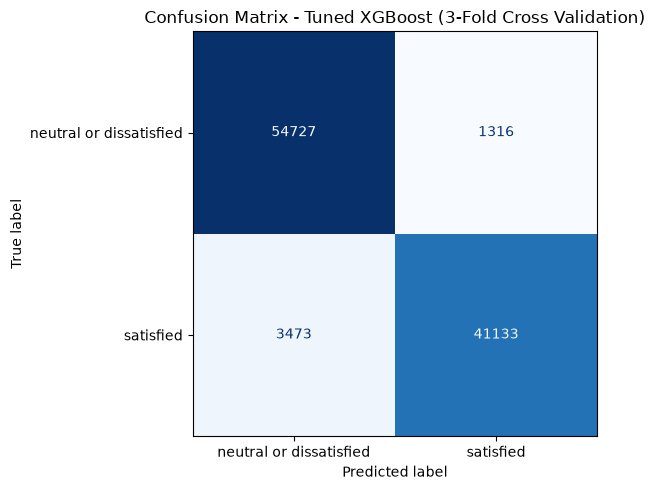

In [18]:
# Cross-validated predictions
y_pred_cv = cross_val_predict(
    estimator=final_xgb_model,
    X=X_train_df,
    y=y_train_encoded,
    cv=skf,
    method="predict",
    n_jobs=-1
)

# Confusion Matrix
cm = confusion_matrix(
    y_train_encoded,
    y_pred_cv
)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Confusion Matrix - Tuned XGBoost (3-Fold Cross Validation)")
plt.grid(False)
plt.tight_layout()
plt.show()